### chair의 이미지 해상도 통일하여 적용하기

In [ ]:
from PIL import Image
import numpy as np

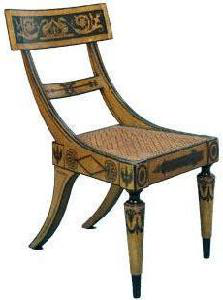

In [2]:
# chair의 1번 이미지
img = Image.open("../Data/chair/image_0001.jpg")
img

In [3]:
# 배열 크기 확인
np.array(img).shape

(300, 223, 3)

In [4]:
# chair의 2번 이미지
img = Image.open("../Data/chair/image_0002.jpg")
np.array(img).shape

(300, 200, 3)

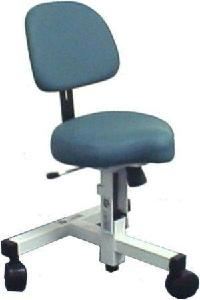

In [5]:
img

> Image의 해상도가 일정하지 않다  
전체 이미지 해상도의 평균값을 가지고 적용

### 전체 이미지 평균 해상도 구하기

In [6]:
import glob

In [7]:
widthRatio = []
heightRatio = []

for file in sorted(glob.glob('../Data/chair/*.jpg')):
    img = np.array(Image.open(file), dtype = np.int32)
    widthRatio.append(img.shape[1])
    heightRatio.append(img.shape[0])

for file in sorted(glob.glob('../Data/laptop/*.jpg')):
    img = np.array(Image.open(file), dtype = np.int32)
    widthRatio.append(img.shape[1])
    heightRatio.append(img.shape[0])

In [8]:
print('전체 너비 평균 해상도 :', np.mean(widthRatio))
print('전체 높이 평균 해상도 :', np.mean(heightRatio))

전체 너비 평균 해상도 : 262.34166666666664
전체 높이 평균 해상도 : 282.2083333333333


> 너비 : 264, 높이 : 284 로 정함

---
#### chair 이미지 해상도 및 흑백 이미지 변경

In [9]:
i = 1
for file in sorted(glob.glob('../Data/chair/*.jpg')):
    img = Image.open(file)
    imgResize = img.resize((264, 284), Image.Resampling.LANCZOS)
    imgResize = imgResize.convert('L')
    imgResize.save(f'../Data/chairNew/image_{i:02}.jpg', "JPEG") # f-string 문법. i:02 -> 십의자리 까지 지정한다
    i += 1

#### Laptop 이미지 해상도 및 흑백 이미지 변경

In [10]:
i = 1
for file in sorted(glob.glob('../Data/laptop/*.jpg')):
    img = Image.open(file)
    imgResize = img.resize((264, 284), Image.Resampling.LANCZOS)
    imgResize = imgResize.convert('L')
    imgResize.save(f'../Data/laptopNew/image_{i:02}.jpg', "JPEG") # f-string 문법. i:02 -> 십의자리 까지 지정한다
    i += 1

---
#### chiar image를 Numpy로 변경하기

In [11]:
number_of_data = 60
img_width_size = 264
img_height_size = 284

In [12]:
chairData = np.zeros(
    number_of_data * img_width_size * img_height_size,
    dtype = np.int32
).reshape(
    number_of_data,
    img_height_size,
    img_width_size
)
chairData.shape

(60, 284, 264)

> -> width = row = 행 / height = column = 열

In [13]:
i = 0
for file in sorted(glob.glob('../Data/chairNew/*.jpg')):
    img = np.array(Image.open(file), dtype = np.int32)
    chairData[i, :, :] = img
    i += 1
chairData.shape

(60, 284, 264)

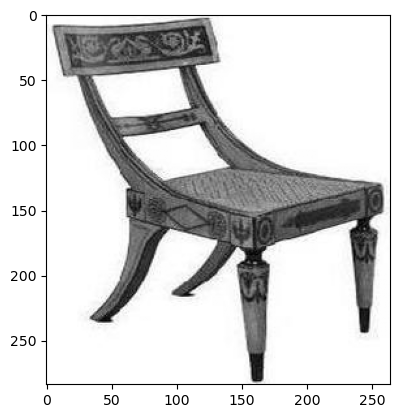

In [14]:
# 이미지 확인하기
import matplotlib.pyplot as plt
plt.imshow(chairData[0].reshape(284, 264), cmap='gray')
plt.show()

#### laptop image 를 Numpy 배열로 변경

In [15]:
laptopData = np.zeros(
    number_of_data * img_width_size * img_height_size,
    dtype = np.int32
).reshape(
    number_of_data,
    img_height_size,
    img_width_size
)
laptopData.shape

(60, 284, 264)

In [16]:
i = 0
for file in sorted(glob.glob('../Data/laptopNew/*.jpg')):
    img = np.array(Image.open(file), dtype = np.int32)
    laptopData[i, :, :] = img
    i += 1
laptopData.shape

(60, 284, 264)

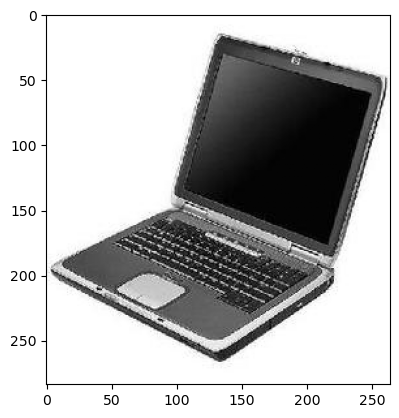

In [17]:
# 이미지 확인하기
import matplotlib.pyplot as plt
plt.imshow(laptopData[0].reshape(284, 264), cmap='gray')
plt.show()

---
#### Train Data 로 합치기

In [18]:
train = np.concatenate(
    [chairData, laptopData]
)
train.shape

(120, 284, 264)

#### Target Data 만들기

In [19]:
target = np.concatenate(
    [np.zeros(60), np.ones(60)]
)
target.shape

(120,)

---
### CNN 으로 정확도 측정하기
1. 정규화 + 채널 추가
2. Train 과 Test 분리
3. CNN 만들기
4. 시각화
5. 평가(evaluate로 Train 과 Test 평가)

In [28]:
from sklearn.model_selection import train_test_split

In [43]:
train_data, test_data, train_target, test_target = \
    train_test_split(
        train,
        target,
        test_size=0.2,
        random_state=42
    )

In [44]:
# 크기 확인
print(train_data.shape)
print(test_data.shape)
print(train_target.shape)
print(test_target.shape)

(96, 284, 264)
(24, 284, 264)
(96,)
(24,)


CNN 구축

Epoch 1/40
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.5000 - loss: 2.4247 - val_accuracy: 0.3000 - val_loss: 8.7589
Epoch 2/40
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.5263 - loss: 3.9282 - val_accuracy: 0.2500 - val_loss: 0.8987
Epoch 3/40
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.5921 - loss: 0.8789 - val_accuracy: 0.7000 - val_loss: 0.6244
Epoch 4/40
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 554ms/step - accuracy: 0.4868 - loss: 0.7284 - val_accuracy: 0.7500 - val_loss: 0.6795
Epoch 5/40
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 621ms/step - accuracy: 0.6711 - loss: 0.6576 - val_accuracy: 0.7500 - val_loss: 0.6573
Epoch 6/40
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 576ms/step - accuracy: 0.7368 - loss: 0.6164 - val_accuracy: 0.4000 - val_loss: 0.6993
Epoch 7/40
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.7763 - loss: 0.5398 - val_accuracy: 0.7000 - val_loss: 0.6078
Epoch 8/40
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 578ms/step - accuracy: 0.9079 - loss: 0.4678 - val_accuracy: 0.6000 - val_loss: 0.6176
Epoc

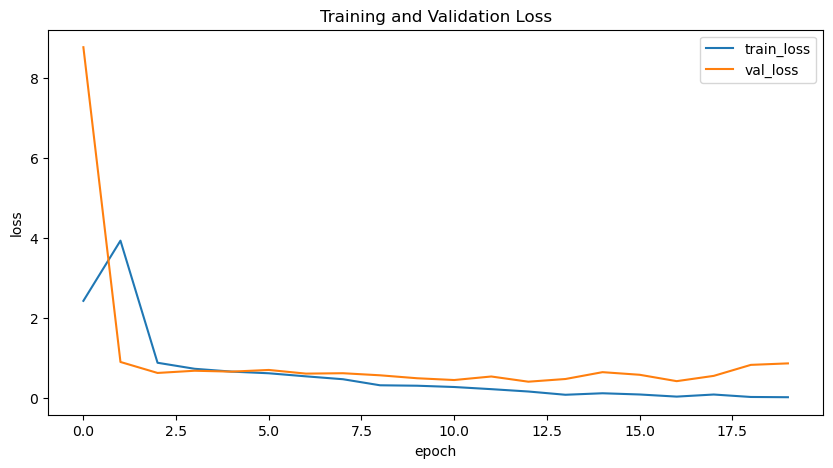

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.9167 - loss: 0.2439

🥇 최적의 에포크: 13 epoch
--------------------------------------------------
📈 [Train]       훈련 정확도: 93.42%
🧪 [Validation]  검증 정확도: 85.00%
🎯 [Test]        🎯 최종 테스트 정확도: 91.67%


In [45]:
# CNN
import matplotlib.pyplot as plt
import numpy as np
#from sklearn.model_selection import train_test_split
from tensorflow import keras

# 1. 데이터 불러오기 및 전처리
# (train_input, train_target), (test_input, test_target) = (
#     keras.datasets.fashion_mnist.load_data()
# )

# 픽셀값을 0~1 사이로 정규화하고 채널 차원(1) 추가
train_scaled = train_data.reshape(-1, 284, 264, 1) / 255.0
test_scaled = test_data.reshape(-1, 284, 264, 1) / 255.0

# 검증 세트 분리
train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42
)

# 2. CNN 모델 구축
model = keras.Sequential(
    [
        keras.Input(shape=(284, 264, 1)),
        # 합성곱 층 1
        keras.layers.Conv2D(
            32,
            kernel_size=3,
            activation="relu",
            padding="same",
        ),
        keras.layers.MaxPooling2D(2),
        # 합성곱 층 2
        keras.layers.Conv2D(
            64, kernel_size=3, activation="relu", padding="same"
        ),
        keras.layers.MaxPooling2D(2),
        # 1차원으로 펼치기
        keras.layers.Flatten(),
        # 은닉층
        keras.layers.Dense(100, activation="relu"),
        keras.layers.Dense(50, activation="relu"),
        # 드롭아웃 (과대적합 방지)
        keras.layers.Dropout(0.5),
        # 출력층
        keras.layers.Dense(1, activation="sigmoid"),
    ]
)

# 모델 컴파일
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)

# 3. 콜백 설정 및 모델 학습
checkpoint_cb = keras.callbacks.ModelCheckpoint(
    "chair_laptop.keras", save_best_only=True
)
early_stopping_cb = keras.callbacks.EarlyStopping(
    patience=7, restore_best_weights=True
)

history = model.fit(
    train_scaled,
    train_target,
    epochs=40,
    validation_data=(val_scaled, val_target),
    callbacks=[checkpoint_cb, early_stopping_cb]
)

# 4. 학습 결과 시각화 (손실 그래프)
plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.title("Training and Validation Loss")
plt.show()

# 5. 테스트 세트 모델 평가
model.evaluate(test_scaled, test_target)

# # 6. 테스트 세트 첫 번째 이미지 예측 결과 확인
# predictions = model.predict(test_scaled)
# predicted_label = 1 if predictions[0][0] >= 0.5 else 0
# actual_label = test_target[0]

# print(f"예측한 레이블: {predicted_label}")
# print(f"실제 레이블: {actual_label}")

# 7. 최적의 에포크 인덱스 찾기 (검증 손실이 가장 낮았던 시점 기준)
val_loss_list = history.history['val_loss'] # -> model.fit() 함수 실행 결과가 자동으로 history 딕셔너리 변수에 저장됨. 해당 변수에 loss, accuracy, val_loss, val_accuracy 등이 저장됨.
best_epoch_index = np.argmin(val_loss_list) # 리스트 인덱스 (0부터 시작)
best_epoch = best_epoch_index + 1               # 실제 에포크 차수 (1부터 시작)

# 8. 최적 에포크 시점의 Train 및 Valid 정확도 추출
best_train_accuracy = history.history['accuracy'][best_epoch_index]
best_val_accuracy = history.history['val_accuracy'][best_epoch_index]

# 9. 가장 성능이 좋았던 저장된 모델을 불러와 Test 정확도 측정
best_model = keras.models.load_model('chair_laptop.keras')
test_loss, best_test_accuracy = best_model.evaluate(test_scaled, test_target, verbose=0)

# 10. 최종 결과 출력
print("\n" + "="*50)
print(f"🥇 최적의 에포크: {best_epoch} epoch")
print("-"*50)
print(f"📈 [Train]       훈련 정확도: {best_train_accuracy * 100:.2f}%")
print(f"🧪 [Validation]  검증 정확도: {best_val_accuracy * 100:.2f}%")
print(f"🎯 [Test]        🎯 최종 테스트 정확도: {best_test_accuracy * 100:.2f}%")
print("="*50)

> 손실 그래프에서 val_loss 가 튀는 이유 : 학습 데이터가 턱없이 부족하기 때문.

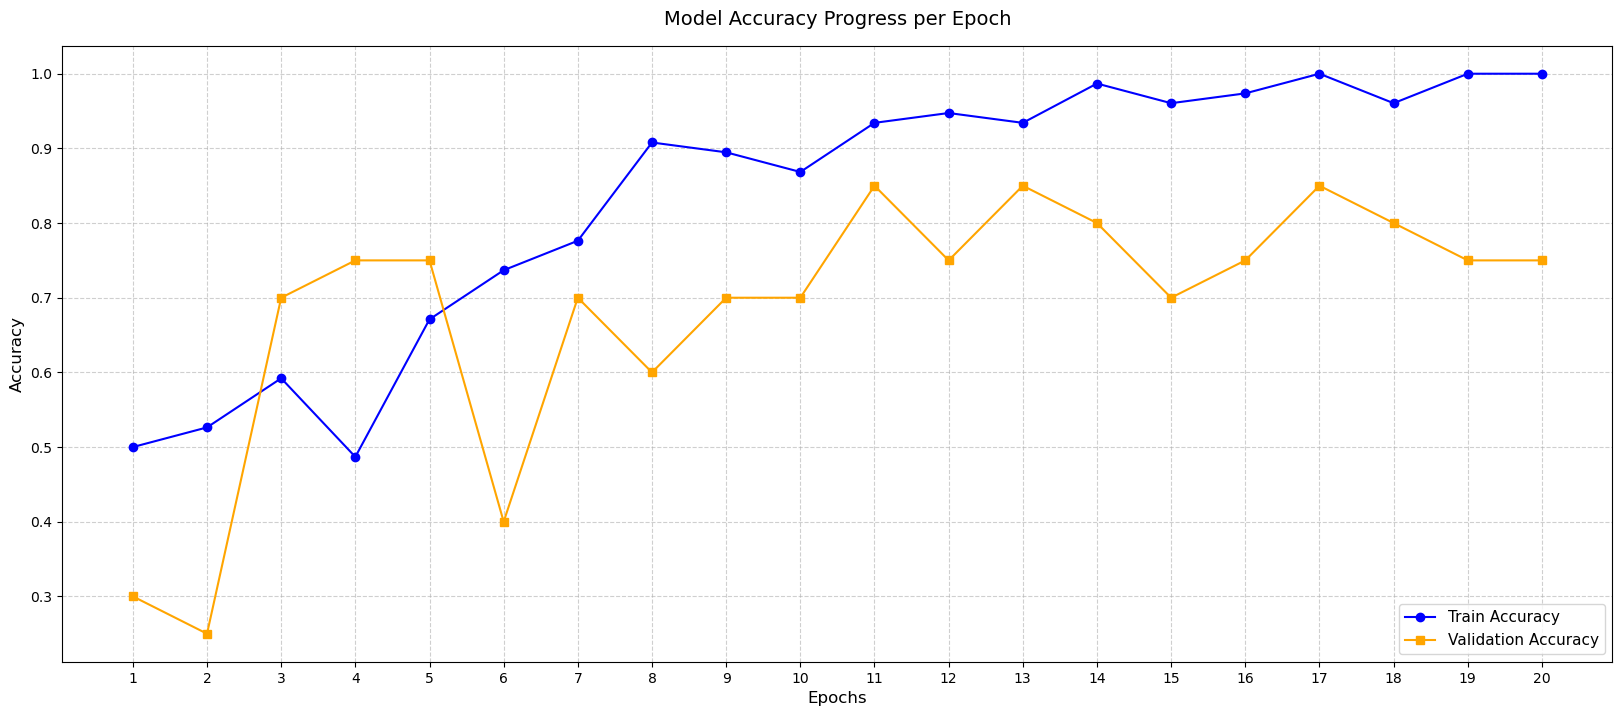

In [46]:
import matplotlib.pyplot as plt

# 1. history 객체에서 에포크별 train, valid 정확도 리스트 추출
train_acc_list = history.history['accuracy']
valid_acc_list = history.history['val_accuracy']

# 2. 에포크 수를 기준으로 x축 설정 (1부터 시작)
epochs_range = range(1, len(train_acc_list) + 1)

# 3. 그래프 그리기
plt.figure(figsize=(20, 8)) # 그래프 크기 설정
plt.plot(epochs_range, train_acc_list, label='Train Accuracy', marker='o', color='blue')
plt.plot(epochs_range, valid_acc_list, label='Validation Accuracy', marker='s', color='orange')

# 4. 그래프 꾸미기 (제목, 축 레이블, 범례 등)
plt.title('Model Accuracy Progress per Epoch', fontsize=14, pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(epochs_range) # x축 눈금을 에포크 정수로 고정
plt.grid(True, linestyle='--', alpha=0.6) # 배경 격자 추가
plt.legend(loc='lower right', fontsize=11) # 범례 위치 설정

# 5. 화면에 그래프 출력
plt.show()